In [ ]:
import kagglehub
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(file)

df.head().T

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.dropna()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


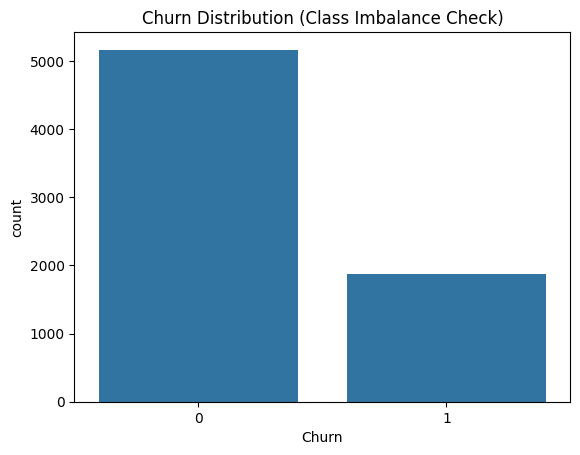

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Churn distribution (class imbalance check)
# This tells us if dataset is balanced or biased
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution (Class Imbalance Check)")
plt.show()

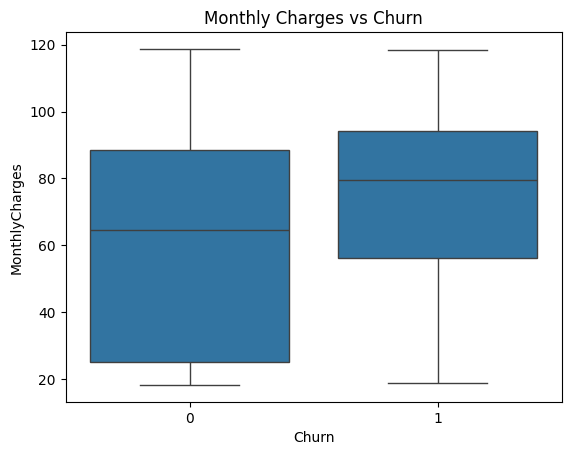

In [ ]:
# Monthly Charges vs Churn
# Helps detect if higher charges lead to churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

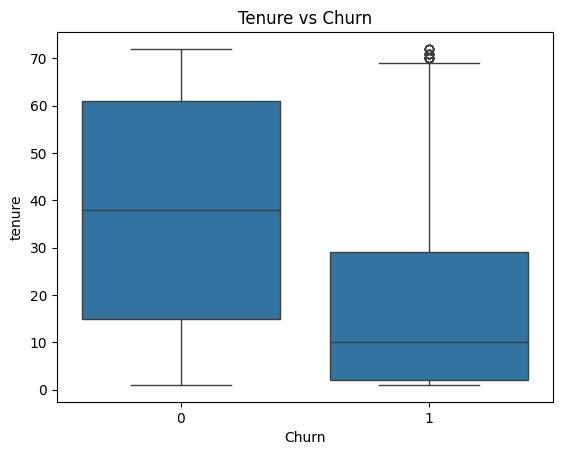

In [ ]:
# Tenure vs Churn
# Very important feature in churn analysis
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

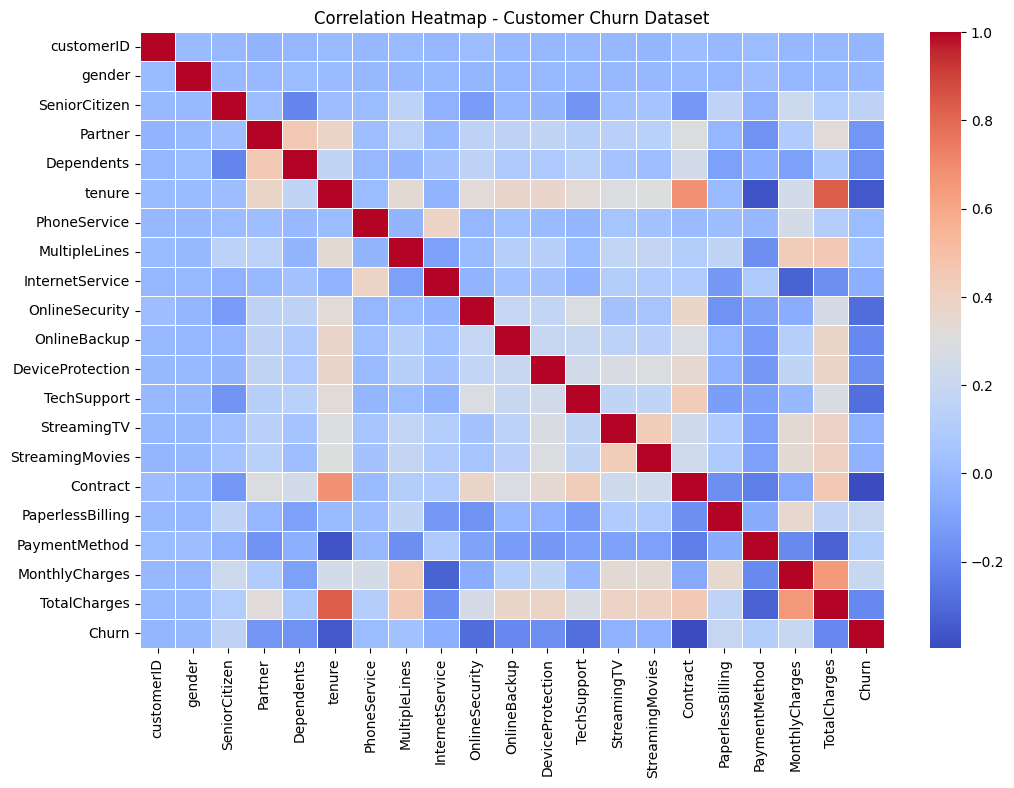

In [ ]:
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False, linewidths=0.5)

plt.title("Correlation Heatmap - Customer Churn Dataset")
plt.show()

In [ ]:
# Target encoding
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Encode categorical columns
cat_cols = df.select_dtypes(include="object").columns
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [ ]:
# Features & target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)



In [ ]:
# -----------------------
# DECISION TREE MODEL
# -----------------------
model = DecisionTreeClassifier(
    max_depth=6,        # controls complexity (prevents overfitting)
    min_samples_split=10,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
# -----------------------
# EVALUATION
# -----------------------
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[943  92]
 [225 149]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.86      1035
           1       0.62      0.40      0.48       374

    accuracy                           0.78      1409
   macro avg       0.71      0.65      0.67      1409
weighted avg       0.76      0.78      0.76      1409


ROC-AUC: 0.8164380376656591


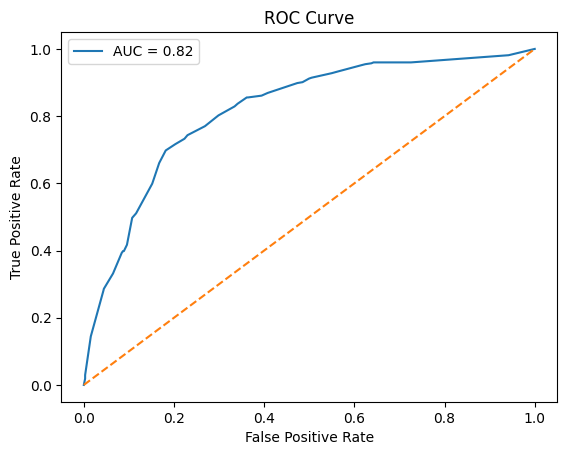

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# -----------------------
# FEATURE IMPORTANCE
# -----------------------
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Features Driving Churn:\n", importance.head(10))


Top Features Driving Churn:
              Feature  Importance
14          Contract    0.494834
8     OnlineSecurity    0.123705
4             tenure    0.114909
7    InternetService    0.082002
17    MonthlyCharges    0.074944
18      TotalCharges    0.055634
9       OnlineBackup    0.013534
0             gender    0.008413
1      SeniorCitizen    0.007226
15  PaperlessBilling    0.006943


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=60,
    max_depth=8,
    min_samples_split=12,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
 [[957  78]
 [202 172]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.92      0.87      1035
           1       0.69      0.46      0.55       374

    accuracy                           0.80      1409
   macro avg       0.76      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409


ROC-AUC: 0.8360484641814565


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Features Driving Churn:\n", importance.head(10))

Confusion Matrix:
 [[962  71]
 [241 133]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.93      0.86      1033
           1       0.65      0.36      0.46       374

    accuracy                           0.78      1407
   macro avg       0.73      0.64      0.66      1407
weighted avg       0.76      0.78      0.75      1407


ROC-AUC: 0.822183454038132

Top Features Driving Churn:
              Feature  Importance
15          Contract    0.237923
5             tenure    0.190679
9     OnlineSecurity    0.138803
12       TechSupport    0.096146
19      TotalCharges    0.088411
11  DeviceProtection    0.050062
10      OnlineBackup    0.049134
8    InternetService    0.048408
18    MonthlyCharges    0.048270
17     PaymentMethod    0.019754
